<a href="https://colab.research.google.com/github/stefanogiagu/corso_AML_2026/blob/main/notebooks/AML_2026_E1_PyTorchIntro_SodaCan_LinearClass_SimpleMLP_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning for Physics 2026

## Hands-on session 1: Recall on Pytorch Framework and ANN


**Scope:** remind usage of Pytroch to implment and train a ANN

**Tasks:** <p>

1.   introduce pytorch library, and solve a simple gradient-based optimization problems using pytorch autograd
3.   implement a tipical DL pipeline in pytorch


**V2.0 - 5.3.2026** - Stefano Giagu <stefano.giagu@uniroma1.it>




**Pytorch** ([pytorch.org](https://pytorch.org/))

Pytorch is a open source ML libray, developed my Met's AI research lab, that leverage GPU acceleration for efficent automatic computation of gradients, and povides APIs for data handling and DL model building and training, which make it easier to develop and test new ideas.

Most appealing features of pytorch:
* pythonic and very concise (very similar to numpy (a GPU-aware numpy))
* strong user base support
* many algorithms and components for DL applications already implemented and accesible via high level APIs

**Example (a computational graph in numpy and in pytorch):**


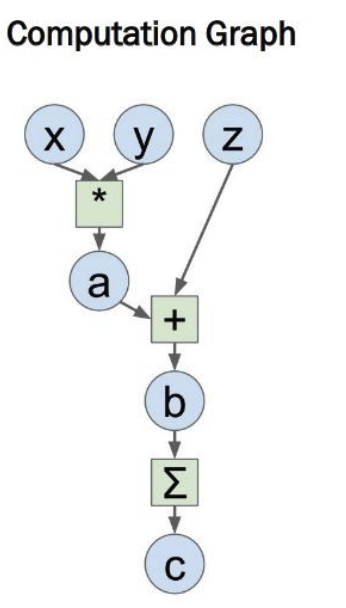

In [ ]:
from IPython.display import Image
Image('http://giagu.web.cern.ch/giagu/CERN/Graph.png', width=200)

In [ ]:
import numpy as np

# numpy implementation

np.random.seed(123)

N,D = 2, 3

x = np.random.randn(N,D)
y = np.random.randn(N,D)
z = np.random.randn(N,D)

a = x*y
b = a+z
c = np.sum(b)

grad_c = 1.0
grad_b = grad_c * np.ones((N,D))
grad_a = grad_b.copy()
grad_z = grad_b.copy()
grad_x = grad_a * y
grad_y = grad_a * x

print(grad_x, grad_y)

[[-2.42667924 -0.42891263  1.26593626]
 [-0.8667404  -0.67888615 -0.09470897]] [[-1.0856306   0.99734545  0.2829785 ]
 [-1.50629471 -0.57860025  1.65143654]]


In [ ]:
import torch

# torch implementation
#torch.manual_seed(123)
#torch.cuda.manual_seed(123)
#torch.cuda.manual_seed_all(123)

N,D = 2, 3

#x = torch.randn((N,D), requires_grad=True)
#y = torch.randn((N,D), requires_grad=True)
#z = torch.randn((N,D), requires_grad=True)

# reading the same input as numpy
x = torch.Tensor(x)
y = torch.Tensor(y)
z = torch.Tensor(z)

x.requires_grad = True
y.requires_grad = True
z.requires_grad = True

a = x*y
b = a+z
c = torch.sum(b)

c.backward()

print(x.grad, y.grad)

tensor([[-2.4267, -0.4289,  1.2659],
        [-0.8667, -0.6789, -0.0947]]) tensor([[-1.0856,  0.9973,  0.2830],
        [-1.5063, -0.5786,  1.6514]])


**Pytorch Tensors**

Torch tensors are similar to NumPy’s ndarrays, with the addition being that Tensors can also be used on a GPU to accelerate computing.

Common operations for creation and manipulation of these Tensors are
similar to those for ndarrays in NumPy. (rand, ones, zeros, indexing,
slicing, reshape, transpose, cross product, matrix product, element wise
multiplication).

In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [ ]:
# in torch/pytorch data and models need to be moved in the specific processing unit
# this code snippet allows to set the variable "device" according to available resoirce (cpu or cuda gpu)

if torch.cuda.is_available():
  print('number fo devices: ', torch.cuda.device_count())
  print(torch.cuda.get_device_name(0))

device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

number fo devices:  1
Tesla T4
Computation device: cuda



**Example of use of pytorch autograd for an optmization task**

Given a cylindrical can of fixed volume $(V_0)$, we want to determine the radius $(r)$ that minimizes the surface-to-volume ratio. The surface area is related to material cost, so minimizing this ratio is important for cost efficiency.

**Define the Surface Area and Volume**

- **Volume**:   $V = \pi r^2 h$

- **Surface Area** (sum of lateral and two circular areas): $ S = 2\pi r h + 2\pi r^2$
$~$

We aim to minimize the ratio $S/V$:

$$ \frac{S}{V} = \frac{2\pi r h + 2\pi r^2}{\pi r^2 h} = \frac{2}{r} + \frac{2}{h}$$

$~$

**Fixed volume $(V_0 = \pi r^2h \Rightarrow h = \frac{V_0}{\pi r^2})$**

$$
\frac{S}{V} = \frac{2}{r} + \frac{2\pi r^2}{V_0}
$$


**Critical Points**

To minimize $(S/V)$, we take the derivative with respect to $(r)$:

$$
\frac{d}{dr} \left( \frac{2}{r} + \frac{2\pi r^2}{V_0} \right) = -\frac{2}{r^2} + \frac{4\pi r}{V_0}
$$

Setting the derivative to zero:

$$
-\frac{2}{r^2} + \frac{4\pi r}{V_0} = 0 \Rightarrow
$$


$$
r = \left(\frac{V_0}{2\pi}\right)^{\frac{1}{3}}
$$

Text(0, 0.5, 'Surface Volume ratio (cm^-1)')

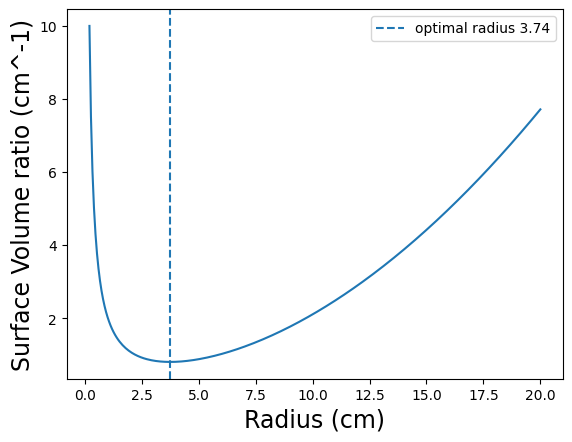

In [ ]:
# let's solve the problem analytically

import matplotlib.pyplot as plt

# data

V0 = 330 #330 cm**3 = 33 cl

SoverV = lambda r: (2/r + (2*np.pi * r **2) / V0)
R_opt = (V0/(2*np.pi))**(1/3)

r = np.linspace(0.2,20,300)
y = SoverV(r)

plt.plot(r,y)
plt.axvline(R_opt,linestyle="--",label=f"optimal radius {np.round(R_opt,2)}")
plt.legend()
plt.xlabel("Radius (cm)" , fontsize =17)
plt.ylabel("Surface Volume ratio (cm^-1)", fontsize =17)

**Let's do the same ting with GD using pytorch**

**Key Steps:**
1. **Initialize Parameters**: Start with random values for the parameters $ \theta $.
2. **Compute the Gradient**: Calculate the derivative (gradient) of the function with respect to the parameters.
3. **Update the Parameters**: Move in the direction of the negative gradient using the update rule:

   $$
   \theta \leftarrow \theta - \eta \nabla f(\theta)
   $$

   where  $\eta$ (learning rate) controls the step size.
4. **Repeat**: Continue updating until convergence (when the gradient is close to zero or changes are minimal).

Optimal radius: 3.763808225486353


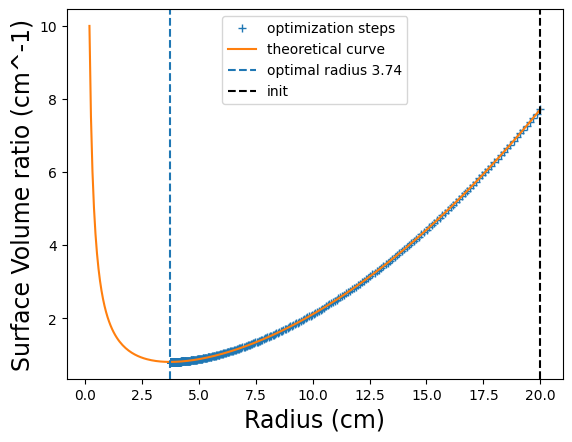

In [ ]:
# let's do the same ting with GD implemented in python

class SoverVoptimizer():
    def __init__(self, V0, learning_rate=0.1, epochs=400):
        self.V0 = V0  # Fixed volume
        self.learning_rate = learning_rate  # Step size

        self.epochs = epochs  # Maximum number of iterations
        self.r_history = []  # Store the radius at each step
        self.f_history = []

    def forward(self, r):
        """Function to optimize: S/V = 2/r + (2 * pi * r^2) / V0"""
        return 2 / r + (2 * np.pi * r ** 2) / self.V0

    def derivative(self, r):# like old timers, we need to compute the derivative by hand
        """Derivative of the objective function."""
        return -2 / r**2 + (4 * np.pi * r) / self.V0

    def do_a_step(self, r):
        """Perform a single step of gradient descent."""
        gradient = self.derivative(r)
        return r - self.learning_rate * gradient  # Update radius

    def optimize(self, r_init):#In machine learnig we call this part "train"
        """Run the gradient descent optimization."""
        r = r_init
        self.r_history.append(r)

        f = self.forward(r)
        self.f_history.append(f)


        for i in range(self.epochs):
            new_r = self.do_a_step(r)
            self.r_history.append(new_r)
            f = self.forward(new_r)
            self.f_history.append(f)
            r = new_r

        return r  # Return the optimized radius



V0 = 330  # Fixed volume
SodaCan = SoverVoptimizer(V0, learning_rate=0.2)
optimal_r = SodaCan.optimize(r_init=20)  # Start from an initial guess of r

print(f"Optimal radius: {optimal_r}")


plt.plot(SodaCan.r_history,SodaCan.f_history,"+",label= "optimization steps")
plt.plot(r,y,label= "theoretical curve")
plt.axvline(R_opt,linestyle="--",label=f"optimal radius {np.round(R_opt,2)}")
plt.xlabel("Radius (cm)" , fontsize =17)
plt.ylabel("Surface Volume ratio (cm^-1)", fontsize =17)
plt.axvline(20,linestyle="--",label="init",color="k")
plt.legend()

Optimal radius using PyTorch: 3.763808250427246


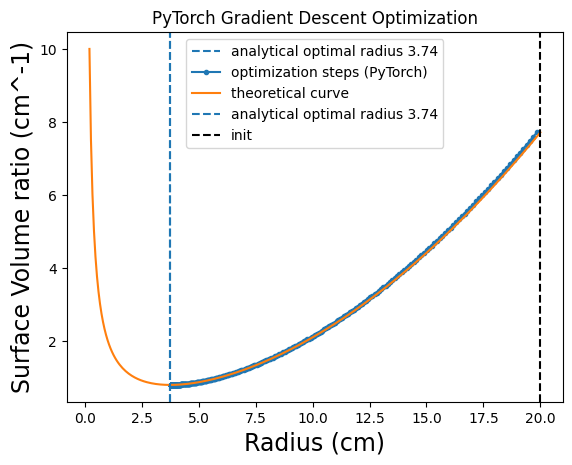

In [ ]:
# now let's do the same using pytorch autograd
import torch

V0 = 330

# starting point (as torch tensor)
r_torch = torch.tensor([20.0], requires_grad=True)

# lr and number of epochs
lr = 0.2
epochs = 400

# history for plotting
r_history_torch = [r_torch.item()]
f_history_torch = []

# objective function (eg loss)
def soverv_torch(r, V0):
  return 2 / r + (2 * np.pi * r**2) / V0

# Optmizer (SGD)
optimizer = torch.optim.SGD([r_torch], lr=lr)

# loop over epochs
for i in range(epochs):
  # zero gradients
  optimizer.zero_grad()

  # forward pass
  f = soverv_torch(r_torch, V0)

  # backward pass (eg compute gradients)
  f.backward()

  # update parameters
  optimizer.step()

  #store history
  r_history_torch.append(r_torch.item())
  f_history_torch.append(f.item())

optimal_r_torch = r_torch.item()
print(f"Optimal radius using PyTorch: {optimal_r_torch}")

R_opt = (V0 / (2 * np.pi))**(1 / 3)
r_plot = np.linspace(0.2, 20, 300)
y_plot = soverv_torch(torch.tensor(r_plot), V0).detach().numpy()

plt.figure()
plt.axvline(R_opt, linestyle="--", label=f"analytical optimal radius {np.round(R_opt,2)}")
plt.plot(r_history_torch[1:], f_history_torch, "o-", label="optimization steps (PyTorch)", markersize=3)
plt.plot(r_plot, y_plot, label="theoretical curve")
plt.axvline(R_opt, linestyle="--", label=f"analytical optimal radius {np.round(R_opt,2)}")
plt.xlabel("Radius (cm)", fontsize=17)
plt.ylabel("Surface Volume ratio (cm^-1)", fontsize=17)
plt.axvline(20, linestyle="--", label="init", color="k")
plt.legend()
plt.title("PyTorch Gradient Descent Optimization")
plt.show()

## Using pytorch to define and train a MLP neural network

In [ ]:
# Dataset: in this simple toy example, we'll produce a toy dataset generated using numpy:
#
# A two class problem, with 8 uncorrelated features, gaussian distributed with different
# means and variance among features and classes

features_S = np.random.normal(loc=[-4.,-3.,-2.,-1.,1.,2.,3.,4.], scale=np.random.uniform(0.2,0.7,size=(8)), size=(2000,8))
features_B = np.random.normal(loc=[-4.5,-3.5,-2.5,-1.5,1.5,2.5,3.5,4.5], scale=np.random.uniform(0.2,0.7,size=(8)), size=(2000,8))
labels_S = np.zeros(shape=(2000))
labels_B = np.ones(shape=(2000))

X = np.concatenate((features_S, features_B), axis=0)
Y = np.concatenate((labels_S, labels_B), axis=0)

# divide the dataset in train and test
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=12345)
X_train, X_vali, Y_train, Y_vali = train_test_split(X_train, Y_train, test_size=0.2, random_state=456789)
print(X_train.shape)
print(Y_train.shape)
print(X_vali.shape)
print(Y_vali.shape)
print(X_test.shape)
print(Y_test.shape)

(2560, 8)
(2560,)
(640, 8)
(640,)
(800, 8)
(800,)


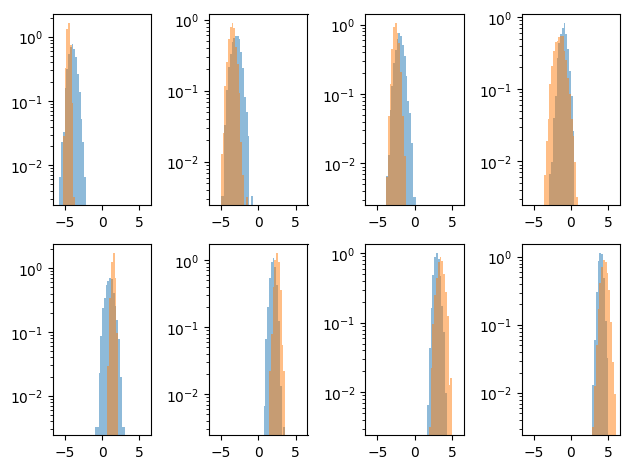

In [ ]:
# plot variables

sel_S = tuple([Y_train<0.5])
sel_B = tuple([Y_train>0.5])

for idx in range(8):
  plt.subplot(2,4,idx+1)
  plt.hist((X_train[sel_S])[:,idx], bins=50, range=[-6.,6.], alpha=0.5, log=True, density=True)
  plt.hist((X_train[sel_B])[:,idx], bins=50, range=[-6.,6.], alpha=0.5, log=True, density=True)
plt.tight_layout()

In [ ]:
# features in general should be normalized [0,1] or [-1.1] or normal(0,1)
# will skip this in this simple example!


# convert numpy arrays in torch tensors (as pytorch works only with torch tensors)

X_train_pt = torch.Tensor(X_train).float()
Y_train_pt = torch.Tensor(Y_train).float()
X_vali_pt = torch.Tensor(X_vali).float()
Y_vali_pt = torch.Tensor(Y_vali).float()
X_test_pt = torch.Tensor(X_test).float()
Y_test_pt = torch.Tensor(Y_test).float()

print(X_train_pt.shape)
print(Y_train_pt.shape)
print(X_vali_pt.shape)
print(Y_vali_pt.shape)
print(X_test_pt.shape)
print(Y_test_pt.shape)

# create a pytorch dataset )pytorch structure able to handle datasets (input, output pairs) and a pytroch dataloader (a python iterable that allows to iterate among sample's events
# mini-batch it, reshuffle at every epoch, etc...)
from torch.utils.data import TensorDataset, DataLoader

dataset_train = TensorDataset(X_train_pt, Y_train_pt)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

dataset_vali = TensorDataset(X_vali_pt, Y_vali_pt)
dataloader_vali = DataLoader(dataset_vali, batch_size=32, shuffle=True)

dataset_test = TensorDataset(X_test_pt, Y_test_pt)
dataloader_test = DataLoader(dataset_test, batch_size=1)

torch.Size([2560, 8])
torch.Size([2560])
torch.Size([640, 8])
torch.Size([640])
torch.Size([800, 8])
torch.Size([800])


In [ ]:
# note: how to move torch tensors between cpu and gpu

print('X_train_pt is in GPU: ', X_train_pt.is_cuda)
X_train_pt = X_train_pt.to(device)
print('X_train_pt is in GPU: ', X_train_pt.is_cuda)
X_train_pt = X_train_pt.to('cpu')
print('X_train_pt is in GPU: ', X_train_pt.is_cuda)


# alteranative way (earlier troch style)
# use .cuda() e .cpu()
print('X_train_pt is in GPU: ', X_train_pt.cpu())
print('X_train_pt is in GPU: ', X_train_pt.cuda())

X_train_pt is in GPU:  False
X_train_pt is in GPU:  True
X_train_pt is in GPU:  False
X_train_pt is in GPU:  tensor([[-3.9912, -3.5739, -1.7079,  ...,  2.4898,  2.8871,  4.0381],
        [-3.6560, -3.7940, -1.7699,  ...,  1.0232,  3.0785,  4.3408],
        [-4.2203, -4.0809, -2.5045,  ...,  2.7551,  3.2631,  4.1852],
        ...,
        [-4.6957, -2.9419, -0.9507,  ...,  2.2836,  3.6743,  4.0821],
        [-3.6823, -3.5538, -1.8417,  ...,  1.8427,  3.0984,  4.0728],
        [-4.8197, -3.5057, -2.5136,  ...,  2.1364,  4.0096,  4.6546]])
X_train_pt is in GPU:  tensor([[-3.9912, -3.5739, -1.7079,  ...,  2.4898,  2.8871,  4.0381],
        [-3.6560, -3.7940, -1.7699,  ...,  1.0232,  3.0785,  4.3408],
        [-4.2203, -4.0809, -2.5045,  ...,  2.7551,  3.2631,  4.1852],
        ...,
        [-4.6957, -2.9419, -0.9507,  ...,  2.2836,  3.6743,  4.0821],
        [-3.6823, -3.5538, -1.8417,  ...,  1.8427,  3.0984,  4.0728],
        [-4.8197, -3.5057, -2.5136,  ...,  2.1364,  4.0096,  4.6546]],


In [ ]:
# example of iteration through the dataloader

train_features, train_labels = next(iter(dataloader_train))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

an_event = train_features[0].squeeze()
a_label = train_labels[0]

print(f"Feature: {an_event}")
print(f"Label: {a_label}")

Feature batch shape: torch.Size([32, 8])
Labels batch shape: torch.Size([32])
Feature: tensor([-4.4844, -3.5341, -2.7778, -1.3321,  1.4060,  2.6793,  3.6625,  4.6001])
Label: 1.0


In [ ]:
# a pytorch nn model: it is just a python class inheriting from nn.Module that defines
# the layers and activations used in the DNN model and a forward(x) method that defines
# how the model act on an input example x (gradients will be autoamtically calucalted by pytorch
# autograd)

from torch import nn
import torch.nn.functional as F

class MyMLP(nn.Module):
  def __init__(self, input_dim):
    super(MyMLP, self).__init__()

    self.input_dim = input_dim

    self.layer1 = nn.Linear(self.input_dim, 20)
    self.activ1 = nn.ReLU()
    self.layer2 = nn.Linear(20, 50)
    self.activ2 = nn.ReLU()
    self.layer3 = nn.Linear(50, 100)
    self.activ3 = nn.ReLU()
    self.layer4 = nn.Linear(100, 1)
    self.activ4 = nn.Sigmoid()

  def forward(self, x): #forward method
    out = self.layer1(x)
    out = self.activ1(out) #we use ReLU as activations for hidden layers
    out = self.layer2(out)
    out = self.activ2(out)
    out = self.layer3(out)
    out = self.activ3(out)
    out = self.layer4(out)
    out = self.activ4(out)
    return out   #output activation is a sigmoid (OK for bynary classification)


# alternative implementation (more modular)
class MyMLP2(nn.Module):
  def __init__(self, input_dim):
    super(MyMLP2, self).__init__()

    self.input_dim = input_dim

    self.mlp_block = nn.Sequential( #similar to keras keras.Sequential module
      nn.Linear(self.input_dim, 20),
      nn.ReLU(),
      nn.Linear(20, 50),
      nn.ReLU(),
      nn.Linear(50, 100),
      nn.ReLU()
    )

    self.out_block = nn.Linear(100, 1)

  def forward(self, x):
    out = torch.sigmoid(self.out_block(self.mlp(x)))
    return out

In [ ]:
#%pip install torchsummary #not needed in colab

In [ ]:
model = MyMLP(input_dim=8)
print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(1,8))
else:
  summary(model, input_size=(1,8))

MyMLP(
  (layer1): Linear(in_features=8, out_features=20, bias=True)
  (activ1): ReLU()
  (layer2): Linear(in_features=20, out_features=50, bias=True)
  (activ2): ReLU()
  (layer3): Linear(in_features=50, out_features=100, bias=True)
  (activ3): ReLU()
  (layer4): Linear(in_features=100, out_features=1, bias=True)
  (activ4): Sigmoid()
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 20]             180
              ReLU-2                [-1, 1, 20]               0
            Linear-3                [-1, 1, 50]           1,050
              ReLU-4                [-1, 1, 50]               0
            Linear-5               [-1, 1, 100]           5,100
              ReLU-6               [-1, 1, 100]               0
            Linear-7                 [-1, 1, 1]             101
           Sigmoid-8                 [-1, 1, 1]               0
Total params: 6,431

In [ ]:
#install torchmetrics: collection of useful PyTorch metrics implementations and an easy-to-use API to create custom metrics]
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.6 MB/s eta 0:00:00


In [ ]:
# reinstantiate a new model (reset weight etc) and put it on GPU
model = MyMLP(input_dim=8)
model.to(device) #nedd to move the model to the computational device
print('model is on GPU: ',next(model.parameters()).is_cuda)

model is on GPU:  True


In [ ]:
#loss

# NOTE: BCELoss for binary classification
#       CrossEntropyLoss for multiclass classification (already includes softmax calculation, in such a case the output of the ANN foward method are logits)
loss_fun = nn.BCELoss() #binary cross entropy loss
#loss_fun = nn.CrossEntropyLoss()

# metrics
import torchmetrics
from torchmetrics.classification import Accuracy

metric_fun = Accuracy(task="binary", num_classes=2)
#metric_fun = Accuracy(task="multiclass", num_classes=3)
metric_fun = metric_fun.to(device) #NOTE: must be moved on the computation device (operation not needed for pytorch loss )

#metric binary accuracy (hand's made)
def my_binary_accuracy(yhat, y):
  assert y.ndim == 1 and y.size() == yhat.size()
  yhat = yhat > 0.5
  return (y == yhat).sum().item() / y.size(0)

my_metric_fun = my_binary_accuracy


# optimizer
from torch import optim
#opt = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
opt = optim.Adam(model.parameters(), lr=1e-3)

# scheduler for multi step decay lr schedule
# Decays the learning rate of each parameter group by gamma once the number of epoch reaches one of the milestones
#lr_scheduler = optim.lr_scheduler.MultiStepLR(opt, milestones=[20,40,60], gamma=0.1)

In [ ]:
# test implementation on one batch before to train (always a good idea to spot possible mistakes)
xb,yb = next(iter(dataloader_train))

xb=xb.type(torch.float).to(device) #put tensors on device
yb=yb.type(torch.float).to(device)

# prediction

pred = model(xb)
print('output shape: ', pred.shape)

# loss and metric
loss = loss_fun(pred, torch.unsqueeze(yb,1))
metric = metric_fun(pred, torch.unsqueeze(yb,1))
#or also: metric = binary_accuracy(torch.squeeze(pred), yb)
mymetric = my_metric_fun(torch.squeeze(pred), yb)

print('loss: ', loss.item())
print('metric: ', metric.item())
print('my_metric: ', mymetric)

output shape:  torch.Size([32, 1])
loss:  0.9241604208946228
metric:  0.34375
my_metric:  0.34375


In [ ]:
#training loop (in pytorch you need to write yourself it (alternatively use PyTorch Lightning for more keras-like APIs))

import time

def train_model(nn_model, criterion, metric, n_epochs, dl_train, dl_vali):


  # liste su cui salvare il valore della loss e della metrica ad ogni epoca per poterli graficare in funzione
  # dell'epoca a fine addestramento
  hist_loss = []
  hist_metric = []
  hist_vloss = []
  hist_vmetric = []


  # loop over epochs
  for epoch in range(n_epochs):
    t0 = time.time()

    # training step
    model.train()
    train_loss = 0
    train_metric = 0
    counter = 0
    for xb, yb in dl_train:
        counter += 1
        xb=xb.to(device)
        yb=yb.to(device)

        pred = nn_model(xb)

        # loss and accuracy
        loss = criterion(pred, torch.unsqueeze(yb,1))
        if metric != None:
          tmetric = metric(pred, torch.unsqueeze(yb,1))

        train_loss += loss.item()
        if metric != None:
          train_metric += tmetric.item()

        # backpropagation
        opt.zero_grad()
        loss.backward()
        opt.step()


    train_loss /= counter
    hist_loss.append(train_loss)

    if metric != None:
      train_metric /= counter
      hist_metric.append(train_metric)


    # validation step (non vengono aggiornati i pesi)
    model.eval()
    vali_loss = 0
    vali_metric = 0
    counter = 0
    with torch.no_grad(): #evita che vengano cacolati automaticamente i gradienti
      for xb, yb in dl_vali:
        counter += 1
        xb=xb.to(device)
        yb=yb.to(device)

        pred = nn_model(xb) #predizione del modello

        # calcolo loss e metrica
        vloss = criterion(pred, torch.unsqueeze(yb,1))
        vali_loss += vloss.item()

        if metric != None:
          vmetric = metric(pred, torch.unsqueeze(yb,1))
          vali_metric += vmetric.item()

    vali_loss /= counter
    hist_vloss.append(vali_loss)

    if metric != None:
      vali_metric /= counter
      hist_vmetric.append(vali_metric)


    elapsed_time = time.time()-t0
    if metric != None:
      print("epoch: %d, time(s): %.4f, train loss: %.6f, train metric: %.6f, vali loss: %.6f, vali metric: %.6f"
            % (epoch+1, elapsed_time, train_loss, train_metric, vali_loss, vali_metric))
    else:
      print("epoch: %d, time(s): %.4f, train loss: %.6f, vali loss: %.6f"
            % (epoch+1, elapsed_time, train_loss, vali_loss))

  return nn_model, hist_loss, hist_metric, hist_vloss, hist_vmetric

In [ ]:
epochs = 100

model, hist_loss, hist_metric, hist_vloss, hist_vmetric = train_model(nn_model=model, criterion=loss_fun, metric=metric_fun, n_epochs=epochs, dl_train=dataloader_train, dl_vali=dataloader_vali)

epoch: 1, time(s): 0.4260, train loss: 0.662807, train metric: 0.616016, vali loss: 0.604845, vali metric: 0.768750
epoch: 2, time(s): 0.4537, train loss: 0.531192, train metric: 0.764062, vali loss: 0.462833, vali metric: 0.807813
epoch: 3, time(s): 0.4371, train loss: 0.438679, train metric: 0.801172, vali loss: 0.404146, vali metric: 0.837500
epoch: 4, time(s): 0.4619, train loss: 0.387774, train metric: 0.827734, vali loss: 0.365399, vali metric: 0.865625
epoch: 5, time(s): 0.4316, train loss: 0.344040, train metric: 0.855078, vali loss: 0.317430, vali metric: 0.870313
epoch: 6, time(s): 0.4421, train loss: 0.302362, train metric: 0.875391, vali loss: 0.278614, vali metric: 0.884375
epoch: 7, time(s): 0.4349, train loss: 0.263350, train metric: 0.890234, vali loss: 0.240178, vali metric: 0.906250
epoch: 8, time(s): 0.4570, train loss: 0.222643, train metric: 0.912500, vali loss: 0.206840, vali metric: 0.914062
epoch: 9, time(s): 0.4538, train loss: 0.178722, train metric: 0.926953,

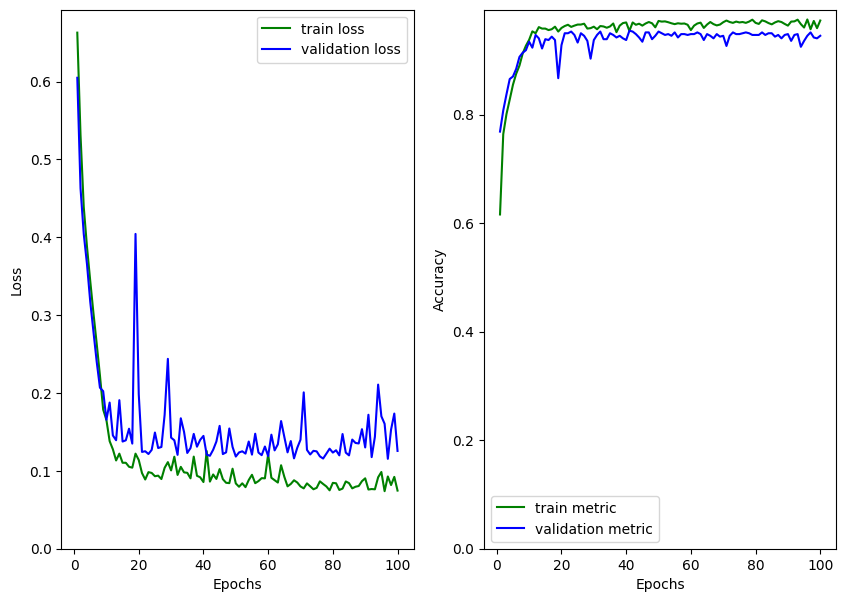

In [ ]:
# plot training results (loss and accuracy vs epoch)
plt.figure(figsize=(10, 7))
plt.subplot(1,2,1)
plt.plot(range(1,len(hist_loss)+1), hist_loss, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(hist_vloss)+1), hist_vloss, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(ymin = 0.0)
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(1,len(hist_metric)+1), hist_metric,  color='green', linestyle='-', label='train metric')
plt.plot(range(1,len(hist_vmetric)+1),hist_vmetric, color='blue', linestyle='-', label='validation metric')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(ymin = 0.0)
plt.legend()

In [ ]:
# save the model
torch.save(model, './trained_model.pt')

In [ ]:
#test the trained model

# read the model
model = torch.load('./trained_model.pt', weights_only=False)
model.eval()

model.to(device)
metric_fun.to(device)


loss = 0
metric = 0
counter = 0

with torch.no_grad():
  for xb, yb in dataloader_test:
    counter += 1
    xb=xb.to(device)
    yb=yb.to(device)
    pred = model(xb)

    loss += loss_fun(pred, torch.unsqueeze(yb,1)).item()
    metric += metric_fun(pred,torch.unsqueeze(yb,1)).item()

  loss /= counter
  metric /= (counter)

print('Test loss/accuracy: ',loss, ' / ', metric)

Test loss/accuracy:  0.09810049987853468  /  0.96875
